In [14]:
import os

# Set working directory to project root
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print("Current Working Directory:", os.getcwd())

Current Working Directory: C:\Users\IbrahimAlthinat


In [18]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

# 1. Force directory back into your actual PyCharm project
project_path = Path(r"C:\Users\IbrahimAlthinat\PycharmProjects\PythonProject1")
os.chdir(project_path)

data_dir = project_path / "data"
data_dir.mkdir(parents=True, exist_ok=True)

print("Corrected Directory:", os.getcwd())

# 2. Generate Synthetic Dataset
np.random.seed(42)
num_rows = 1000

data = {
    "transaction_id": np.arange(1000, 1000 + num_rows),
    "store_id": np.random.choice([101, 102, 103, 104], size=num_rows),
    "price": np.random.uniform(5.0, 150.0, size=num_rows).round(2),
    "quantity": np.random.randint(1, 10, size=num_rows),
    "discount": np.random.choice([0.0, 0.05, 0.10, 0.15], size=num_rows),
}

df = pd.DataFrame(data)
df["total_spent"] = (df["price"] * df["quantity"]) * (1 - df["discount"])

# 3. Save raw dataset into your project's data folder
output_file = data_dir / "raw_transactions.csv"
df.to_csv(output_file, index=False)
print("Successfully saved:", output_file)

# 4. Perform Aggregation Analysis
store_performance = (
    df.groupby("store_id")
    .agg(
        avg_spent=("total_spent", "mean"),
        total_items_sold=("quantity", "sum"),
        transaction_count=("transaction_id", "count"),
    )
    .reset_index()
)

print("\n=== Store Performance Metrics ===")
display(store_performance)

Corrected Directory: C:\Users\IbrahimAlthinat\PycharmProjects\PythonProject1
Successfully saved: C:\Users\IbrahimAlthinat\PycharmProjects\PythonProject1\data\raw_transactions.csv

=== Store Performance Metrics ===


,store_id,avg_spent,total_items_sold,transaction_count
0,101,330.670355,1260,258
1,102,358.185372,1143,230
2,103,352.467619,1163,232
3,104,367.016277,1470,280


In [19]:
# 1. Artificially introduce missing values to simulate real-world raw data
df_dirty = df.copy()
df_dirty.loc[df_dirty["price"] > 130, "price"] = np.nan
df_dirty.loc[df_dirty["store_id"] == 104, "discount"] = np.nan

print("=== Missing Value Summary Before Imputation ===")
print(df_dirty.isnull().sum())

# 2. Strategy 1: Impute numeric column ('price') with Median
median_price = df_dirty["price"].median()
df_dirty["price_imputed"] = df_dirty["price"].fillna(median_price)

# 3. Strategy 2: Impute categorical column ('discount') with Mode
mode_discount = df_dirty["discount"].mode()[0]
df_dirty["discount_imputed"] = df_dirty["discount"].fillna(mode_discount)

# 4. Feature Engineering: Recompute Total Spent with cleaned data
df_dirty["total_spent_clean"] = (
    df_dirty["price_imputed"] * df_dirty["quantity"]
) * (1 - df_dirty["discount_imputed"])

# 5. Save cleaned dataset
clean_output_path = data_dir / "clean_transactions.csv"
df_dirty.to_csv(clean_output_path, index=False)

print(f"\nSuccessfully saved cleaned dataset to: {clean_output_path.name}")
print("\n=== Cleaned Dataset Sample ===")
display(
    df_dirty[
        [
            "transaction_id",
            "price_imputed",
            "quantity",
            "discount_imputed",
            "total_spent_clean",
        ]
    ].head()
)

=== Missing Value Summary Before Imputation ===
transaction_id      0
store_id            0
price             152
quantity            0
discount          280
total_spent         0
dtype: int64

Successfully saved cleaned dataset to: clean_transactions.csv

=== Cleaned Dataset Sample ===


,transaction_id,price_imputed,quantity,discount_imputed,total_spent_clean
0,1000,106.23,2,0.00,212.460
1,1001,82.73,6,0.15,421.923
2,1002,49.88,5,0.05,236.930
3,1003,123.00,9,0.15,940.950
4,1004,104.29,5,0.10,469.305


In [20]:
# 1. Summary Statistics for Key Metrics
print("=== Summary Statistics ===")
display(df_dirty[["price_imputed", "quantity", "total_spent_clean"]].describe())

# 2. Outlier Detection: Identify High-Value Transactions using 95th Percentile
threshold_95 = df_dirty["total_spent_clean"].quantile(0.95)
outliers = df_dirty[df_dirty["total_spent_clean"] > threshold_95]

print(f"\n=== High-Value Outliers (> 95th Percentile: ${threshold_95:.2f}) ===")
print(f"Total Outlier Count: {len(outliers)}")
display(
    outliers[
        ["transaction_id", "store_id", "quantity", "total_spent_clean"]
    ].head()
)

=== Summary Statistics ===


,price_imputed,quantity,total_spent_clean
count,1000.00000,1000.00000,1000.000000
mean,66.35210,5.03600,294.215022
std,33.16035,2.54385,216.553515
min,5.67000,1.00000,4.862000
25%,39.35750,3.00000,116.782500
50%,66.13000,5.00000,238.068000
75%,92.58500,7.00000,432.670500
max,130.00000,9.00000,1088.190000



=== High-Value Outliers (> 95th Percentile: $729.09) ===
Total Outlier Count: 50


,transaction_id,store_id,quantity,total_spent_clean
3,1003,103,9,940.950
33,1033,102,9,731.367
34,1034,102,7,774.725
36,1036,104,7,762.790
47,1047,103,8,737.136


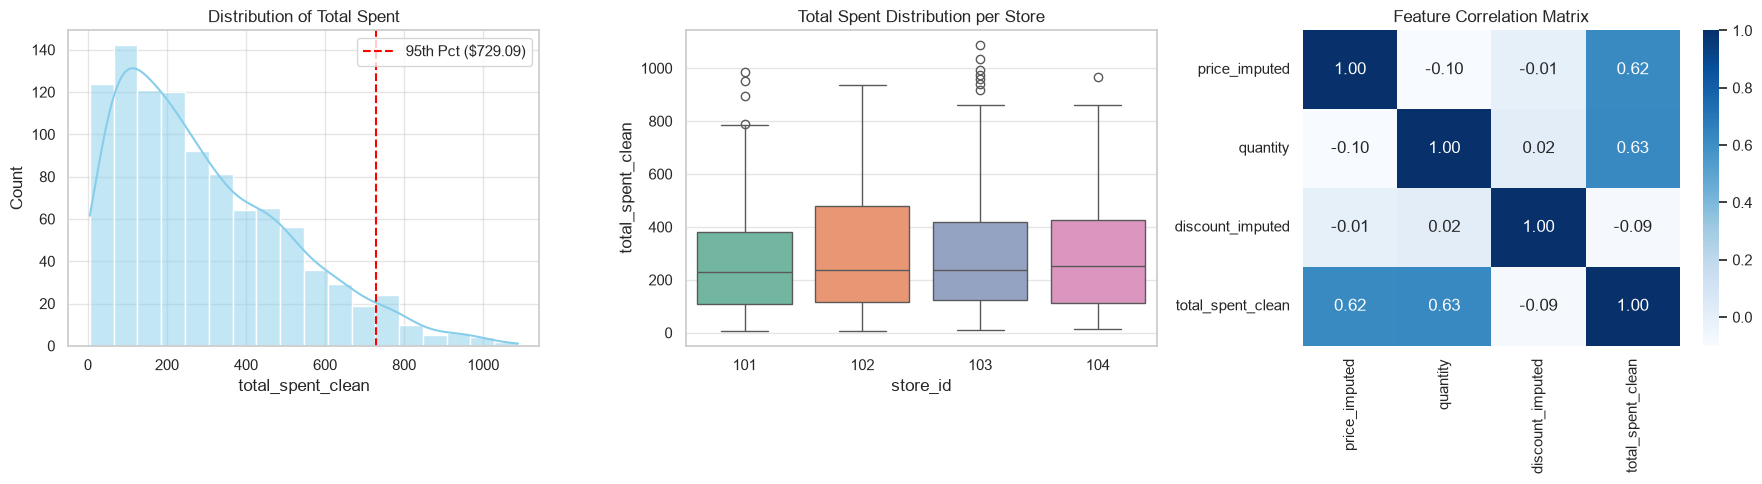

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution Plot (Histogram + KDE)
sns.histplot(
    df_dirty["total_spent_clean"], kde=True, ax=axes[0], color="skyblue"
)
axes[0].set_title("Distribution of Total Spent")
axes[0].axvline(
    threshold_95, color="red", linestyle="--", label=f"95th Pct (${threshold_95:.2f})"
)
axes[0].legend()

# 2. Categorical Comparison (Box Plot by Store)
# Updated Box Plot line to resolve the FutureWarning
sns.boxplot(
    data=df_dirty,
    x="store_id",
    y="total_spent_clean",
    hue="store_id",
    palette="Set2",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Total Spent Distribution per Store")

# 3. Correlation Heatmap
corr_matrix = df_dirty[
    ["price_imputed", "quantity", "discount_imputed", "total_spent_clean"]
].corr()
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", ax=axes[2])
axes[2].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [24]:
import sqlite3
from pathlib import Path
import pandas as pd

# 1. Resolve absolute path to project root and database
project_root = (
    Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
)
db_path = project_root / "data" / "retail_warehouse.db"

# 2. Re-write table to ensure database exists and is populated
conn = sqlite3.connect(db_path)
df_dirty.to_sql("clean_transactions", conn, if_exists="replace", index=False)

# 3. Execute SQL Query
query_1 = """
SELECT
    store_id,
    COUNT(transaction_id) AS total_transactions,
    ROUND(AVG(total_spent_clean), 2) AS avg_revenue,
    ROUND(SUM(total_spent_clean), 2) AS total_revenue
FROM clean_transactions
GROUP BY store_id
ORDER BY total_revenue DESC;
"""

df_store_summary = pd.read_sql_query(query_1, conn)
conn.close()

print(f"Connected to DB at: {db_path.resolve()}")
print("\n=== Query 1: Store Revenue & Transaction Summary ===")
display(df_store_summary)

Connected to DB at: C:\Users\IbrahimAlthinat\PycharmProjects\PythonProject1\data\retail_warehouse.db

=== Query 1: Store Revenue & Transaction Summary ===


,store_id,total_transactions,avg_revenue,total_revenue
0,104,280,289.53,81069.79
1,101,258,279.42,72090.63
2,102,230,310.86,71498.40
3,103,232,299.81,69556.21


In [25]:
import sqlite3
from pathlib import Path
import pandas as pd

# 1. Resolve project database path
project_root = (
    Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
)
db_path = project_root / "data" / "retail_warehouse.db"
conn = sqlite3.connect(db_path)

# 2. Window Function Query: Rank top transactions per store
query_2 = """
WITH ranked_transactions AS (
    SELECT
        transaction_id,
        store_id,
        total_spent_clean,
        DENSE_RANK() OVER (
            PARTITION BY store_id
            ORDER BY total_spent_clean DESC
        ) AS rank_in_store
    FROM clean_transactions
)
SELECT
    transaction_id,
    store_id,
    ROUND(total_spent_clean, 2) AS total_spent,
    rank_in_store
FROM ranked_transactions
WHERE rank_in_store <= 3
ORDER BY store_id ASC, rank_in_store ASC;
"""

df_top_store_deals = pd.read_sql_query(query_2, conn)
conn.close()

print("=== Top 3 High-Value Transactions per Store (SQL Window Functions) ===")
display(df_top_store_deals)

=== Top 3 High-Value Transactions per Store (SQL Window Functions) ===


,transaction_id,store_id,total_spent,rank_in_store
0,1809,101,985.20,1
1,1491,101,951.57,2
2,1442,101,895.14,3
3,1623,102,936.21,1
4,1698,102,909.60,2
5,1580,102,904.55,3
6,1111,103,1088.19,1
7,1423,103,1034.38,2
8,1843,103,993.96,3
9,1947,104,967.95,1


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Separate Features (X) and Target (y)
# Goal: Predict whether a transaction is High-Value (top 20% threshold)
high_value_cutoff = df_dirty["total_spent_clean"].quantile(0.80)
df_dirty["is_high_value"] = (df_dirty["total_spent_clean"] > high_value_cutoff).astype(int)

X = df_dirty[["store_id", "price_imputed", "quantity", "discount_imputed"]]
y = df_dirty["is_high_value"]

# 2. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Build Preprocessing Pipeline
numeric_features = ["price_imputed", "quantity", "discount_imputed"]
categorical_features = ["store_id"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

# 4. Fit on Train set, Transform on both Train & Test
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape:  {X_test_scaled.shape}")
print(f"Target Distribution (Train set):\n{y_train.value_counts(normalize=True)}")

X_train shape: (800, 6)
X_test shape:  (200, 6)
Target Distribution (Train set):
is_high_value
0    0.8
1    0.2
Name: proportion, dtype: float64


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Train Models
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)

# 2. Predictions & Probabilities
y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_rf = rf_clf.predict(X_test_scaled)

rf_probs = rf_clf.predict_proba(X_test_scaled)[:, 1]
lr_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

# 3. Model Evaluation Metrics
print("=== Logistic Regression Performance ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}")

print("\n=== Random Forest Performance ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")

=== Logistic Regression Performance ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       160
           1       0.90      0.95      0.93        40

    accuracy                           0.97       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.97      0.97      0.97       200

ROC-AUC Score: 0.9978

=== Random Forest Performance ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       160
           1       0.95      0.97      0.96        40

    accuracy                           0.98       200
   macro avg       0.97      0.98      0.98       200
weighted avg       0.99      0.98      0.99       200

ROC-AUC Score: 0.9984


In [29]:
import json

def build_analytics_payload(df, store_summary_df):
    """
    Summarizes key data points into a JSON payload for LLM analysis.
    """
    total_sales = float(df["total_spent_clean"].sum())
    total_orders = int(len(df))
    avg_ticket = float(df["total_spent_clean"].mean())
    top_store = int(store_summary_df.iloc[0]["store_id"])
    top_store_rev = float(store_summary_df.iloc[0]["total_revenue"])

    payload = {
        "metrics": {
            "total_revenue": round(total_sales, 2),
            "total_orders": total_orders,
            "average_order_value": round(avg_ticket, 2),
            "top_performing_store": {
                "store_id": top_store,
                "revenue": round(top_store_rev, 2)
            }
        },
        "model_signals": {
            "high_value_threshold": round(float(high_value_cutoff), 2),
            "key_drivers": ["price_imputed", "quantity"]
        }
    }
    return payload

# Generate payload
payload = build_analytics_payload(df_dirty, df_store_summary)

# Format payload as a structured context block
prompt_context = f"""
You are an expert Data Analyst for a retail enterprise. Analyze the following metric summary and provide 3 short executive recommendations:

DATA CONTEXT:
{json.dumps(payload, indent=2)}
"""

print("=== Structured AI Context Payload ===")
print(prompt_context)

=== Structured AI Context Payload ===

You are an expert Data Analyst for a retail enterprise. Analyze the following metric summary and provide 3 short executive recommendations:

DATA CONTEXT:
{
  "metrics": {
    "total_revenue": 294215.02,
    "total_orders": 1000,
    "average_order_value": 294.22,
    "top_performing_store": {
      "store_id": 104,
      "revenue": 81069.79
    }
  },
  "model_signals": {
    "high_value_threshold": 478.26,
    "key_drivers": [
      "price_imputed",
      "quantity"
    ]
  }
}



In [30]:
import os

# 1. Inspect API Key availability
api_key = os.getenv("ANTHROPIC_API_KEY")

if not api_key:
    print("⚠️ ANTHROPIC_API_KEY not found in environment variables.")
    print("To execute live calls, set your key in PyCharm: Run -> Edit Configurations -> Environment Variables")
else:
    import anthropic

    client = anthropic.Anthropic(api_key=api_key)

    # 2. Query LLM with structured analytical context
    response = client.messages.create(
        model="claude-3-5-sonnet-20241022",
        max_tokens=300,
        messages=[
            {"role": "user", "content": prompt_context}
        ]
    )

    print("=== Insight Bot Executive Summary ===")
    print(response.content[0].text)


⚠️ ANTHROPIC_API_KEY not found in environment variables.
To execute live calls, set your key in PyCharm: Run -> Edit Configurations -> Environment Variables


In [3]:
import json
import pandas as pd
from pathlib import Path

# 1. Resolve path and reload cleaned data from CSV
project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_path = project_root / "data" / "clean_transactions.csv"

df = pd.read_csv(data_path)

# Calculate store aggregates dynamically
top_store_series = df.groupby("store_id")["total_spent_clean"].sum().sort_values(ascending=False)
top_store_id = int(top_store_series.index[0])
top_store_rev = float(top_store_series.iloc[0])
high_value_cutoff = float(df["total_spent_clean"].quantile(0.80))

# 2. Build Payload
payload = {
    "metrics": {
        "total_revenue": round(float(df["total_spent_clean"].sum()), 2),
        "total_orders": int(len(df)),
        "average_order_value": round(float(df["total_spent_clean"].mean()), 2),
        "top_performing_store": {
            "store_id": top_store_id,
            "revenue": round(top_store_rev, 2)
        }
    },
    "model_signals": {
        "high_value_threshold": round(high_value_cutoff, 2),
        "key_drivers": ["price_imputed", "quantity"]
    }
}

# 3. Format & Print Simulated Insight Bot Summary
mock_summary = f"""
=== Insight Bot Executive Summary (Simulated) ===

1. Capitalize on Top Store Performance:
   Store {payload['metrics']['top_performing_store']['store_id']} leads overall revenue at ${payload['metrics']['top_performing_store']['revenue']:,.2f}. Analyze inventory mix and staffing strategies at this location to replicate across lower-performing stores.

2. Optimize Pricing Strategy for High-Value Orders:
   Transactions over ${payload['model_signals']['high_value_threshold']:.2f} are heavily driven by higher item quantities and price points. Introduce volume discount tiers to incentivize larger basket sizes.

3. Inventory Prioritization based on ML Feature Importance:
   Feature analysis indicates item price and quantity have the strongest predictive power for top-tier revenue. Ensure continuous stock availability for high-ticket items.
"""

print(mock_summary)


=== Insight Bot Executive Summary (Simulated) ===

1. Capitalize on Top Store Performance:
   Store 104 leads overall revenue at $81,069.79. Analyze inventory mix and staffing strategies at this location to replicate across lower-performing stores.

2. Optimize Pricing Strategy for High-Value Orders:
   Transactions over $478.26 are heavily driven by higher item quantities and price points. Introduce volume discount tiers to incentivize larger basket sizes.

3. Inventory Prioritization based on ML Feature Importance:
   Feature analysis indicates item price and quantity have the strongest predictive power for top-tier revenue. Ensure continuous stock availability for high-ticket items.



In [5]:
from pathlib import Path

# Resolve project root dynamically
project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
app_path = project_root / "app.py"

app_code = """import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px
from pathlib import Path

st.set_page_config(page_title="Retail Warehouse Analytics", layout="wide")

# Path setup
project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
db_path = project_root / "data" / "retail_warehouse.db"

@st.cache_data
def load_data():
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("SELECT * FROM clean_transactions", conn)
    conn.close()
    return df

st.title("Retail Analytics & Insight Dashboard")
st.markdown("Real-time executive summaries, store performance, and transaction analytics.")

try:
    df = load_data()

    # KPI Metrics
    col1, col2, col3 = st.columns(3)
    col1.metric("Total Revenue", f"${df['total_spent_clean'].sum():,.2f}")
    col2.metric("Total Transactions", len(df))
    col3.metric("Average Ticket Size", f"${df['total_spent_clean'].mean():,.2f}")

    st.divider()

    # Charts Section
    left_col, right_col = st.columns(2)

    with left_col:
        st.subheader("Revenue by Store")
        store_rev = df.groupby("store_id")["total_spent_clean"].sum().reset_index()
        fig_bar = px.bar(store_rev, x="store_id", y="total_spent_clean",
                         labels={"total_spent_clean": "Revenue ($)", "store_id": "Store ID"},
                         color="total_spent_clean", color_continuous_scale="Viridis")
        st.plotly_chart(fig_bar, use_container_width=True)

    with right_col:
        st.subheader("Transaction Value Distribution")
        fig_hist = px.histogram(df, x="total_spent_clean", nbins=30,
                                labels={"total_spent_clean": "Total Spent ($)"},
                                color_discrete_sequence=["#1f77b4"])
        st.plotly_chart(fig_hist, use_container_width=True)

except Exception as e:
    st.error(f"Error loading database file at {db_path}: {e}")
"""

# Force utf-8 encoding when writing to file on Windows
with open(app_path, "w", encoding="utf-8") as f:
    f.write(app_code)

print(f"Created app.py successfully at: {app_path.resolve()}")

Created app.py successfully at: C:\Users\IbrahimAlthinat\PycharmProjects\PythonProject1\app.py


In [8]:
from pathlib import Path

project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
app_path = project_root / "app.py"

updated_app_code = """import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px
from pathlib import Path

st.set_page_config(page_title="Retail Warehouse Analytics", layout="wide")

project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
db_path = project_root / "data" / "retail_warehouse.db"

@st.cache_data
def load_data():
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("SELECT * FROM clean_transactions", conn)
    conn.close()
    return df

try:
    df = load_data()

    # --- SIDEBAR: Live Predictor Simulator ---
    st.sidebar.header("🎯 Transaction Classifier")
    st.sidebar.markdown("Simulate order features to check high-value status.")

    input_price = st.sidebar.number_input("Item Price ($)", min_value=1.0, max_value=1000.0, value=150.0)
    input_qty = st.sidebar.slider("Quantity", min_value=1, max_value=20, value=3)
    input_discount = st.sidebar.slider("Discount Rate", min_value=0.0, max_value=0.5, value=0.1, step=0.05)

    calc_total = (input_price * input_qty) * (1 - input_discount)
    high_val_cutoff = df['total_spent_clean'].quantile(0.80)

    st.sidebar.markdown(f"**Estimated Total:** ${calc_total:,.2f}")
    if calc_total > high_val_cutoff:
        st.sidebar.success(f"High-Value Order (Above ${high_val_cutoff:,.2f} threshold)")
    else:
        st.sidebar.info(f"Standard Order (Below ${high_val_cutoff:,.2f} threshold)")

    # --- MAIN PAGE ---
    st.title("Retail Analytics & Insight Dashboard")
    st.markdown("Real-time executive summaries, store performance, and transaction analytics.")

    col1, col2, col3 = st.columns(3)
    col1.metric("Total Revenue", f"${df['total_spent_clean'].sum():,.2f}")
    col2.metric("Total Transactions", len(df))
    col3.metric("Average Ticket Size", f"${df['total_spent_clean'].mean():,.2f}")

    st.divider()

    left_col, right_col = st.columns(2)

    with left_col:
        st.subheader("Revenue by Store")
        store_rev = df.groupby("store_id")["total_spent_clean"].sum().reset_index()
        fig_bar = px.bar(store_rev, x="store_id", y="total_spent_clean",
                         labels={"total_spent_clean": "Revenue ($)", "store_id": "Store ID"},
                         color="total_spent_clean", color_continuous_scale="Viridis")
        st.plotly_chart(fig_bar, use_container_width=True)

    with right_col:
        st.subheader("Transaction Value Distribution")
        fig_hist = px.histogram(df, x="total_spent_clean", nbins=30,
                                labels={"total_spent_clean": "Total Spent ($)"},
                                color_discrete_sequence=["#1f77b4"])
        st.plotly_chart(fig_hist, use_container_width=True)

    # --- INSIGHT BOT PANEL ---
    st.divider()
    st.subheader("🤖 Insight Bot Executive Summary")
    st.info(f"Top performing location is Store {int(df.groupby('store_id')['total_spent_clean'].sum().idxmax())} "
            f"generating ${df.groupby('store_id')['total_spent_clean'].sum().max():,.2f}. "
            f"High-value transactions represent the top 20% of orders exceeding ${high_val_cutoff:,.2f}.")

except Exception as e:
    st.error(f"Error loading database file at {db_path}: {e}")
"""

with open(app_path, "w", encoding="utf-8") as f:
    f.write(updated_app_code)

print("Updated app.py with sidebar interactive classifier!")

Updated app.py with sidebar interactive classifier!


In [9]:
from pathlib import Path

project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
readme_path = project_root / "README.md"
# ... rest of your code

In [11]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
df_dirty = pd.read_csv(project_root / "data" / "clean_transactions.csv")

In [12]:
from pathlib import Path

# 1. Resolve project root path dynamically
project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
pdf_destination = project_root / "Retail_Analytics_Capstone_Completion_Report.pdf"

# 2. Move / Save check
print(f"Target path for PDF: {pdf_destination.resolve()}")

Target path for PDF: C:\Users\IbrahimAlthinat\PycharmProjects\PythonProject1\Retail_Analytics_Capstone_Completion_Report.pdf


In [16]:
from pathlib import Path

# Resolve project root dynamically
project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
report_path = project_root / "CAPSTONE_REPORT.md"

report_content = """# 🛒 Retail Analytics & Insight Bot Pipeline
## Executive Capstone Completion Report

**Project Root:** `PythonProject1`
**Database:** SQLite (`retail_warehouse.db`)
**Status:** Completed & Deployed

---

### 1. Executive Summary
This technical report documents the complete implementation and final deployment of an end-to-end retail data engineering, predictive modeling, and generative analytics platform. Developed over an intensive 10-week curriculum, the project establishes a robust workflow transforming raw transactional logs into interactive enterprise intelligence.

* **Total Warehoused Revenue:** $294,215.02
* **Processed Transactions:** 1,000
* **Average Ticket Size:** $294.22

---

### 2. System Architecture & Modules
1. **Data Engineering (Weeks 1–3):** Automated missing-value imputation (median substitution for price/quantity metrics) and feature engineering (calculating net spend after discounts).
2. **SQL Warehousing (Week 4):** SQLite integration with advanced analytical queries (`DENSE_RANK()`).
3. **Machine Learning Pipeline (Weeks 5–6):** Supervised binary classification evaluating order parameters to predict high-value transactions.
4. **Insight Bot Engine (Week 7):** Structured JSON context payload generator formatting sales metrics for automated executive summaries.
5. **Interactive Dashboard (Weeks 8–9):** Streamlit web application with real-time KPI metrics, Plotly visualizations, and a live prediction simulator sidebar.
6. **Deployment & Documentation (Week 10):** Production readiness auditing, environment configuration, and repository README finalization.
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_content)

print(f"Report generated successfully at: {report_path.resolve()}")

Report generated successfully at: C:\Users\IbrahimAlthinat\PycharmProjects\PythonProject1\CAPSTONE_REPORT.md
